Homework 8 – Geopandas Geoprocessing techniques

By Antoaneta Chakarova for Geog592

10/05/2026

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_dir = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data"

community_path = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data/Community_Floodplain/Community_Floodplain.shp"
fema_path = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data/FEMA_Floodplain/FEMA_Floodplain.shp"
drainage_path = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data/drainage.geojson"
fire_path = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data/Current_CFD_Fire_Stations.geojson"
streets_path = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data/streets.geojson"

community = gpd.read_file(community_path)
fema = gpd.read_file(fema_path)
drainage = gpd.read_file(drainage_path)
fire = gpd.read_file(fire_path)
streets = gpd.read_file(streets_path)

In [3]:
print("Community floodplain:", community.shape, community.crs)
print("FEMA floodplain:", fema.shape, fema.crs)
print("Drainage:", drainage.shape, drainage.crs)
print("Fire stations:", fire.shape, fire.crs)
print("Streets:", streets.shape, streets.crs)

print("FEMA columns:")
print(list(fema.columns))

print("Fire station columns:")
print(list(fire.columns))

print("Street columns:")
print(list(streets.columns))

Community floodplain: (354, 6) PROJCS["NAD83 / North Carolina (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",33.75],PARAMETER["central_meridian",-79],PARAMETER["standard_parallel_1",34.3333333333333],PARAMETER["standard_parallel_2",36.1666666666667],PARAMETER["false_easting",2000000.00261667],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
FEMA floodplain: (372, 6) PROJCS["NAD83 / North Carolina (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_o

In [4]:
print("Community:", community.crs, community.total_bounds)
print("FEMA:", fema.crs, fema.total_bounds)
print("Drainage:", drainage.crs, drainage.total_bounds)
print("Fire:", fire.crs, fire.total_bounds)
print("Streets:", streets.crs, streets.total_bounds)

print()
print("Drainage geometry:", drainage.geom_type.value_counts())
print("Fire geometry:", fire.geom_type.value_counts())
print("Streets geometry:", streets.geom_type.value_counts())

Community: PROJCS["NAD83 / North Carolina (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",33.75],PARAMETER["central_meridian",-79],PARAMETER["standard_parallel_1",34.3333333333333],PARAMETER["standard_parallel_2",36.1666666666667],PARAMETER["false_easting",2000000.00261667],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]] [1395269.24990611  460833.05195218 1533490.87110011  644790.61448252]
FEMA: PROJCS["NAD83 / North Carolina (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_

In [5]:
target_crs = "EPSG:2264"

community = community.to_crs(target_crs)
fema = fema.to_crs(target_crs)
drainage = drainage.to_crs(target_crs)
fire = fire.to_crs(target_crs)
streets = streets.to_crs(target_crs)

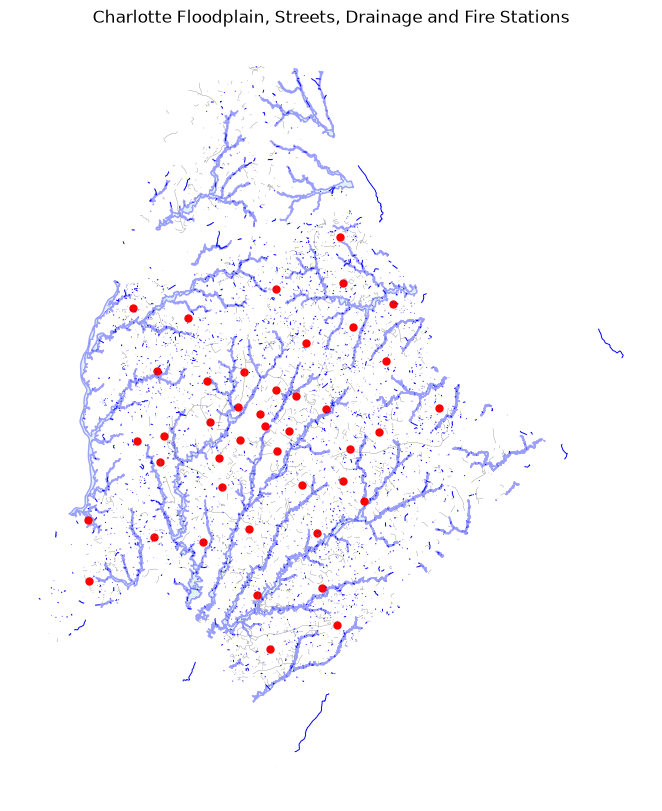

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

community.plot(ax=ax, color="lightblue", alpha=0.35, edgecolor="blue")
streets.plot(ax=ax, color="gray", linewidth=0.25)
drainage.plot(ax=ax, color="blue", linewidth=0.7)
fire.plot(ax=ax, color="red", markersize=25)

ax.set_title("Charlotte Floodplain, Streets, Drainage and Fire Stations")
ax.set_axis_off()
plt.show()

AI usage: I used AI (ChatGPT) in order to fix my issues with the geojson query download. I experienced issues where it would always download as a text or json file, or in one case it was a geojson but showed Fire Station data for Californian coordinates instead of Charlotte, NC. I copy pasted the query page into ChatGPT and asked it how to fill in the fields, it gave me 2 fields that I really needed - Where: 1=1, Out Fields: *. With these filled out everything worked as intended. 